In [1]:
import pandas as pd
import numpy as np
import networkx as nx
from itertools import combinations, product
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import os

from tqdm import tqdm
from sdv.metadata import SingleTableMetadata
from sdv.single_table import CopulaGANSynthesizer, TVAESynthesizer, CTGANSynthesizer
from sklearn.metrics import r2_score
from scipy.interpolate import CubicSpline, PchipInterpolator, Akima1DInterpolator

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.api import ExponentialSmoothing

import optuna

device = torch.device('cpu')

# plt.style.use('ggplot')
plt.style.use('default')

import matplotlib as mpl
#set params for the article
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['axes.labelsize'] = 18

#set params for the notebook
# mpl.rcParams['xtick.labelsize'] = 12
# mpl.rcParams['ytick.labelsize'] = 12
# mpl.rcParams['legend.fontsize'] = 10
# mpl.rcParams['axes.labelsize'] = 14


# import category_encoders as ce

In [2]:
data = pd.read_csv('train_data.csv')
data = data.drop(['Этаж', 'Район', 'id', 'date', 'rooms', 'Цена', 'nprice'], axis=1)
data['day'] = pd.to_datetime(data['day'])
data['date'] = data['day']
data['month'] = data['day'].dt.month
data['year'] = data['day'].dt.year
data['day'] = data['day'].dt.day
data = data.dropna()
data = pd.concat([data.drop('pricemetr', axis=1), data['pricemetr']], axis=1)

In [3]:
data = data.sort_values(by='date').reset_index(drop=True)

In [4]:
data

,Площадь квартиры,day,количество этажей всего,высота объекта,Этажность объекта подземная,Этажность объекта наземная,Количество квартир,Общая площадь объекта,Площадь жилых помещений объекта,lon,...,cemetprox,industrprox,daysin,daycos,liveratio,highratio,date,month,year,pricemetr
0,74.54,9,10.0,39.77,1.0,12.0,105.0,14021.45,10127.91,37.449120,...,0.025636,0.092323,0.154309,0.988023,0.722315,3.314167,2017-01-09,1,2017,0.080756
1,51.14,9,10.0,39.77,1.0,12.0,105.0,14021.45,10127.91,37.449120,...,0.025636,0.092323,0.154309,0.988023,0.722315,3.314167,2017-01-09,1,2017,0.089729
2,27.92,11,7.0,26.00,1.0,7.0,382.0,17592.80,15221.76,37.126686,...,0.030034,0.150462,0.188227,0.982126,0.865227,3.714286,2017-01-11,1,2017,0.150468
3,38.89,11,7.0,26.00,1.0,7.0,382.0,17592.80,15221.76,37.126686,...,0.030034,0.150462,0.188227,0.982126,0.865227,3.714286,2017-01-11,1,2017,0.157270
4,28.00,11,18.0,63.90,2.0,16.0,377.0,47872.00,21659.00,37.698572,...,0.020048,0.016641,0.188227,0.982126,0.452436,3.993750,2017-01-11,1,2017,0.363360
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251602,37.90,30,18.0,55.98,1.0,17.0,650.0,44942.40,26672.60,37.640677,...,0.024976,0.009009,-0.999991,0.004304,0.593484,3.292941,2024-09-30,9,2024,0.312265
251603,47.30,30,49.0,171.19,2.0,47.0,1273.0,113568.00,68775.20,37.536522,...,0.016034,0.011047,-0.999991,0.004304,0.605586,3.642340,2024-09-30,9,2024,0.481625
251604,87.10,30,49.0,171.19,2.0,47.0,1273.0,113568.00,68775.20,37.536522,...,0.016034,0.011047,-0.999991,0.004304,0.605586,3.642340,2024-09-30,9,2024,0.461412
251605,19.50,30,18.0,55.98,1.0,17.0,650.0,44942.40,26672.60,37.640677,...,0.024976,0.009009,-0.999991,0.004304,0.593484,3.292941,2024-09-30,9,2024,0.383528


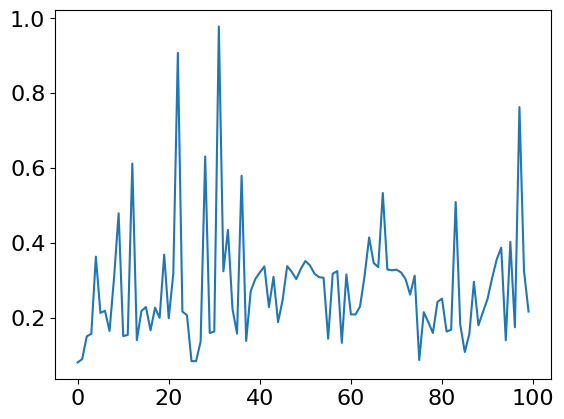

In [5]:
plt.plot(data['pricemetr'].iloc[:100])
plt.show()

In [6]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import shap

In [7]:
data = data.drop('date', axis=1)

In [8]:
X, y = data.drop('pricemetr', axis=1), data['pricemetr']

In [9]:
y

0         0.080756
1         0.089729
2         0.150468
3         0.157270
4         0.363360
            ...   
251602    0.312265
251603    0.481625
251604    0.461412
251605    0.383528
251606    0.267290
Name: pricemetr, Length: 251607, dtype: float64

In [10]:
data

,Площадь квартиры,day,количество этажей всего,высота объекта,Этажность объекта подземная,Этажность объекта наземная,Количество квартир,Общая площадь объекта,Площадь жилых помещений объекта,lon,...,schoolprox,cemetprox,industrprox,daysin,daycos,liveratio,highratio,month,year,pricemetr
0,74.54,9,10.0,39.77,1.0,12.0,105.0,14021.45,10127.91,37.449120,...,0.002639,0.025636,0.092323,0.154309,0.988023,0.722315,3.314167,1,2017,0.080756
1,51.14,9,10.0,39.77,1.0,12.0,105.0,14021.45,10127.91,37.449120,...,0.002639,0.025636,0.092323,0.154309,0.988023,0.722315,3.314167,1,2017,0.089729
2,27.92,11,7.0,26.00,1.0,7.0,382.0,17592.80,15221.76,37.126686,...,0.022235,0.030034,0.150462,0.188227,0.982126,0.865227,3.714286,1,2017,0.150468
3,38.89,11,7.0,26.00,1.0,7.0,382.0,17592.80,15221.76,37.126686,...,0.022235,0.030034,0.150462,0.188227,0.982126,0.865227,3.714286,1,2017,0.157270
4,28.00,11,18.0,63.90,2.0,16.0,377.0,47872.00,21659.00,37.698572,...,0.003442,0.020048,0.016641,0.188227,0.982126,0.452436,3.993750,1,2017,0.363360
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251602,37.90,30,18.0,55.98,1.0,17.0,650.0,44942.40,26672.60,37.640677,...,0.007366,0.024976,0.009009,-0.999991,0.004304,0.593484,3.292941,9,2024,0.312265
251603,47.30,30,49.0,171.19,2.0,47.0,1273.0,113568.00,68775.20,37.536522,...,0.006508,0.016034,0.011047,-0.999991,0.004304,0.605586,3.642340,9,2024,0.481625
251604,87.10,30,49.0,171.19,2.0,47.0,1273.0,113568.00,68775.20,37.536522,...,0.006508,0.016034,0.011047,-0.999991,0.004304,0.605586,3.642340,9,2024,0.461412
251605,19.50,30,18.0,55.98,1.0,17.0,650.0,44942.40,26672.60,37.640677,...,0.007366,0.024976,0.009009,-0.999991,0.004304,0.593484,3.292941,9,2024,0.383528


## Baseline regression

In [28]:
scaler = MinMaxScaler()
data = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)

X_train, X_test, y_train, y_test = train_test_split(data.drop('pricemetr', axis=1), data['pricemetr'], test_size=0.3, random_state=55555)

xgb = XGBRegressor()

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [29]:
xgb_pred = xgb.predict(X_test)

In [30]:
mean_absolute_percentage_error(y_test.values, xgb_pred), r2_score(y_test.values, xgb_pred)

(0.0958119686031835, 0.8540512019094606)

In [ ]:
# z = 0.5
# f = lambda arr: np.array(list(map(lambda y: 2 * y + 0.1, arr)))

# idx = X_test[X_test['floor'] > z].index

# plt.scatter(X_test['floor'].loc[idx], y_test.loc[idx])
# plt.scatter(X_test['floor'].loc[idx], f(y_test.loc[idx]))

# plt.show()

In [ ]:
# sc_target = f(y_test.loc[idx])

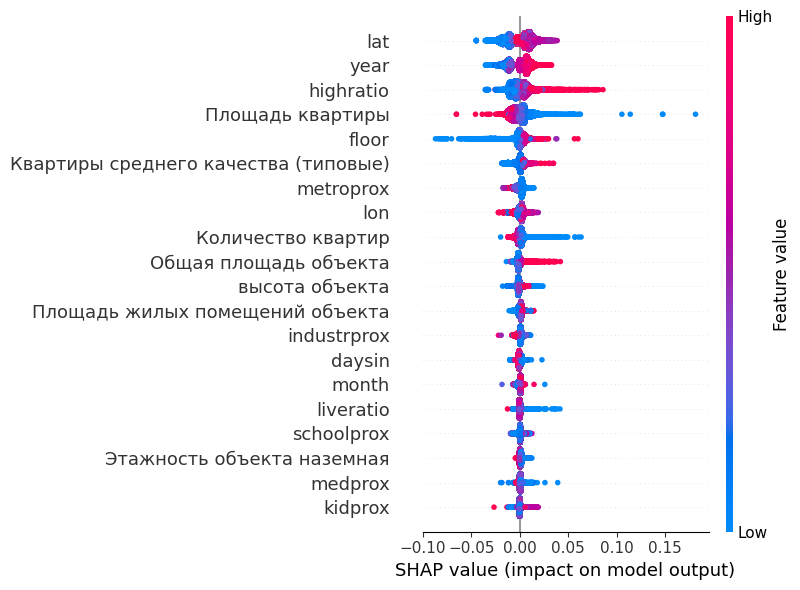

In [33]:
explainer = shap.TreeExplainer(xgb)
explanation = explainer(X_test)
shap.summary_plot(explanation, plot_size=[8,6])

## Distillation

In [1190]:
class RegressionDistill(nn.Module):
    def __init__(self, in_dim):
        super(RegressionDistill, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(in_dim, 2**8),
            nn.ReLU(),
            nn.Linear(2**8, 2**8),
            nn.ReLU(),
            nn.Linear(2**8, 1),
        )
        
    def forward(self, x):
        out = self.model(x)
        
        return out
    
    
class DataseCustom(torch.utils.data.Dataset):
    def __init__(self, data, data_distill):
        self.data = data
        self.data_distill = data_distill

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return [self.data[idx], self.data_distill[idx]]

In [1191]:
data_reg = np.array(data).astype('float32')
data_reg = torch.tensor(data_reg).to(device)

y_for_distill = torch.tensor(xgb.predict(data.drop('pricemetr', axis=1)).reshape(-1, 1)).to(device)

reg_dataset = DataseCustom(data_reg, y_for_distill)
reg_loader = torch.utils.data.DataLoader(reg_dataset, batch_size=256, shuffle=True)

In [1192]:
reg_model = RegressionDistill(X.shape[1]).to(device)
optim_reg = optim.AdamW(reg_model.parameters(), lr=3e-4)

epochs = tqdm(range(200))

for _ in epochs:
    for data_x, data_d in reg_loader:
        
        reg_pred = reg_model(data_x[:, :-1])
        
        loss = 0.1 * torch.mean( (reg_pred - data_x[:, -1])**2 ) + torch.mean( (reg_pred - data_d)**2 )
        
        optim_reg.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(reg_model.parameters(), max_norm=1)
        optim_reg.step()
        
    epochs.set_description(f'{loss.item()}')

0.00018205524247605354: 100%|██████████| 200/200 [06:43<00:00,  2.02s/it]


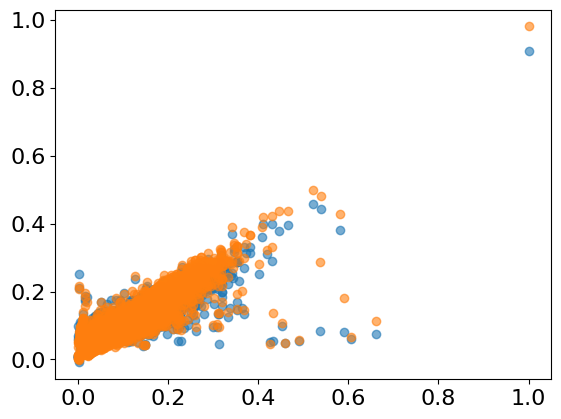

In [1193]:
plt.scatter(y_train.values, reg_model(torch.tensor(X_train.values.astype('float32')).to(device)).detach().cpu().numpy().T[0], alpha=0.6)
plt.scatter(y_train.values, xgb.predict(X_train), alpha=0.6)

plt.show()

In [1194]:
reg_model.eval()

for param in reg_model.parameters():
    param.requires_grad = False

In [1195]:
mean_absolute_percentage_error(y_test.values, xgb.predict(X_test)), r2_score(y_test.values, xgb.predict(X_test))

(0.0958119686031835, 0.8540512019094606)

## Generator

In [1196]:
class DataseCustomScenario(torch.utils.data.Dataset):
    def __init__(self, data_wo_x, X_for_sc, y_sc):
        self.data_wo_x = data_wo_x
        self.y_sc = y_sc
        self.X_for_sc = X_for_sc

    def __len__(self):
        return len(self.data_wo_x)

    def __getitem__(self, idx):
        return [self.data_wo_x[idx], self.X_for_sc[idx], self.y_sc[idx]]
    
z = 0.7
idx_sc = data[data['floor'] > z].index
f = lambda arr: np.array(list(map(lambda y: 0.5 * y + 0.3, arr))) #+  0.1 * np.sin(np.linspace(0, 1, len(arr))*5)

# def f(data):
#     sc = lambda arr: np.array(list(map(lambda y: 0.5 * y, arr))) + 0.1 * np.sin(np.linspace(0, 1, len(arr))*5)
    
#     idx_after_sort = data.loc[idx_sc, 'pricemetr'].sort_values().index
#     y_sc = data.loc[idx_sc, 'pricemetr'].sort_values().values.astype('float32')
#     y_sc = pd.DataFrame(sc(y_sc))
    
#     y_sc.index = idx_after_sort
#     y_sc = y_sc.loc[idx_sc].values.astype('float32')

#     return y_sc

data_wo_x = torch.tensor(data.loc[idx_sc].drop(['floor', 'pricemetr'], axis=1).values.astype('float32'))

# y_sc = torch.tensor( f(data.loc[idx_sc, 'pricemetr'].values.astype('float32')) ).view(-1, 1)
# y_sc = f(data)
y_sc = np.array(sorted(np.array(list(zip(np.arange(len(idx_sc)), data['floor'].loc[idx_sc].values, f(data.loc[idx_sc,'pricemetr'])))), key=lambda x: x[1]))
y_sc[:, 2] = y_sc[:, 2] + 0.1 *  np.linspace(0, 1, len(y_sc))
y_sc = np.array(sorted(y_sc, key=lambda x: x[0]))
y_sc = torch.tensor(y_sc[:, 2].astype('float32')).view(-1, 1)


X_for_sc = torch.tensor(data.loc[idx_sc, 'floor'].values.astype('float32')).view(-1, 1)


sc_dataset = DataseCustomScenario(data_wo_x.unsqueeze(1), X_for_sc, y_sc)
sc_loader = torch.utils.data.DataLoader(sc_dataset, batch_size=256, shuffle=True)

In [1197]:
# sc = lambda arr: np.array(list(map(lambda y: 0.5 * y + 0.2, arr))) + 0.1 * np.sin(10 * np.linspace(0, 1, len(arr)))

# idx_after_sort = data.loc[idx_sc, 'pricemetr'].sort_values().index
# y_sc = data.loc[idx_sc, 'pricemetr'].sort_values().values.astype('float32')
# y_sc = pd.DataFrame(sc(y_sc))

# y_sc.index = idx_after_sort
# y_sc = y_sc.loc[idx_sc].values.astype('float32')

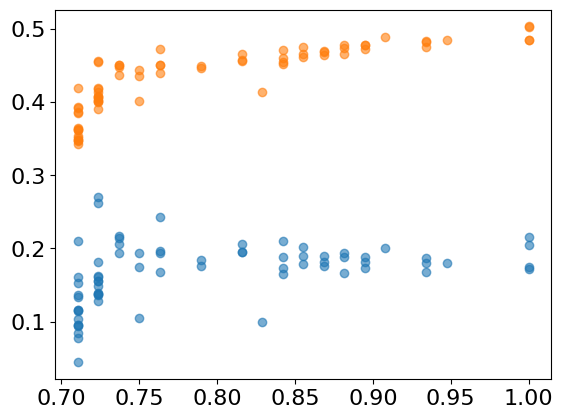

In [1198]:
plt.scatter(data['floor'].loc[idx_sc], data.loc[idx_sc, 'pricemetr'], alpha=0.6)
# plt.scatter(data['floor'].loc[idx_sc], f(data.loc[idx_sc,'pricemetr']), alpha=0.6)
plt.scatter(data['floor'].loc[idx_sc], y_sc, alpha=0.6)
# plt.scatter(data['floor'].loc[idx_sc], xgb.predict(synth_df), alpha=0.6)

plt.show()

In [1199]:
pos = np.where(data.columns == 'floor')[0][0]

In [1209]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding='same')
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=3, padding='same')
        self.bn2 = nn.BatchNorm1d(channels)
        
        self.act = nn.SiLU()
        
        self.drop1 = nn.Dropout(0.2)
        self.drop2 = nn.Dropout(0.2)

    def forward(self, x):
        skip = x
        out = self.conv1(x)
        out = self.act(out)
        out = out + skip
        out = self.bn1(out)
        out = self.drop1(out)
        
        # skip2 = out
        # out = self.conv2(out)
        # out = self.act(out)
        # out = out + skip2
        # out = self.bn2(out)
        # out = self.drop2(out)
        
        return out

# VAE model definition
class VAE(nn.Module):
    def __init__(self, input_channels=1, seq_length=128, latent_dim=16, hidden_channels=32):
        super(VAE, self).__init__()
        self.seq_length = seq_length
        self.latent_dim = latent_dim
        self.hidden_channels = hidden_channels

        
        self.enc_conv1 = nn.Conv1d(input_channels, hidden_channels, kernel_size=3, padding='same')
        self.enc_bn1 = nn.BatchNorm1d(hidden_channels)
        self.enc_res1 = ResidualBlock(hidden_channels)
   
        self.enc_conv2 = nn.Conv1d(hidden_channels, hidden_channels, kernel_size=3, padding='same')
        self.enc_bn2 = nn.BatchNorm1d(hidden_channels)
        self.enc_res2 = ResidualBlock(hidden_channels)

        self.h_dim_enc = seq_length * hidden_channels
        
        self.fc_mu = nn.Sequential(nn.Linear(self.h_dim_enc, latent_dim))
        self.fc_logvar = nn.Sequential(nn.Linear(self.h_dim_enc, latent_dim))
        self.fc_decode = nn.Sequential(nn.Linear(latent_dim, self.h_dim_enc))


        self.dec_conv1 = nn.ConvTranspose1d(hidden_channels, hidden_channels, kernel_size=3, padding=1, output_padding=0)
        self.dec_bn1 = nn.BatchNorm1d(hidden_channels)
        self.dec_res1 = ResidualBlock(hidden_channels)
    
        self.dec_conv2 = nn.ConvTranspose1d(hidden_channels, hidden_channels, kernel_size=3, padding=1, output_padding=0)
        self.dec_res2 = ResidualBlock(hidden_channels)
        self.dec_conv3 = nn.ConvTranspose1d(hidden_channels, input_channels, kernel_size=1)
        
        self.act = nn.SiLU()

    def encode(self, x):
        # skip = x
        x = self.enc_conv1(x)
        
        x = self.act(x)
        # x = self.enc_bn1(x)
        x = self.enc_res1(x)
        
        x = self.enc_conv2(x)
        x = self.act(x)
        # x = self.enc_bn2(x)
        x = self.enc_res2(x)
        
        x = x.view(x.size(0), -1)
        
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        # conv_out_length = (self.seq_length) // 4
        x = self.fc_decode(z)
        
        x = x.view(z.size(0), self.hidden_channels, self.seq_length)
        
        
        x = self.dec_conv1(x)
        
        x = self.act(x)
        # x = self.dec_bn1(x)
        x = self.dec_res1(x)
        
        x = self.dec_conv2(x)
        x = self.dec_res2(x)
        
        x = self.dec_conv3(x)
        
        return F.sigmoid(x)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar
    
    

def vae_loss(recon_x, x, X_for_sc, y_sc, mu, logvar, beta, reg_model):
    recon_loss = F.mse_loss(recon_x, x, reduction='mean')
    kl_loss = torch.mean( -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp() , dim=1) )
    
    
    left = recon_x.squeeze(1)[:, :pos]
    right = recon_x.squeeze(1)[:, pos:]
    result_tensor = torch.cat((left, X_for_sc, right), dim=1)
    reg_pred_synth = reg_model(result_tensor)
    
    ml_loss = torch.mean( (reg_pred_synth - y_sc)**2 )
    
    return 0.01 * recon_loss + beta * kl_loss + 2 * ml_loss


def train_vae(model, train_loader, reg_model, num_epochs=500, learning_rate=1e-3, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        # device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=2e-4)
    beta_sch = torch.cat([torch.tensor(np.linspace(0.0, 0.0005, num_epochs//2)), torch.tensor(np.linspace(0.0005, 0.0005, num_epochs//2))]).float().to(device)
    
    epochs = tqdm(range(num_epochs))
    
    losses = []
    model.train()
    for epoch in epochs:
        epoch_loss = 0
        
        for data, X_for_sc, y_sc in train_loader:
            data = data.to(device)
            
            recon_data, mu, logvar = model(data)
            
            loss = vae_loss(recon_data, data, X_for_sc, y_sc, mu, logvar, beta_sch[epoch], reg_model)
            
            optimizer.zero_grad()
            loss.backward()
            norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
            optimizer.step()
        
            epoch_loss += loss.item()
            
        scheduler.step()
        
        
        avg_loss = epoch_loss / len(train_loader.dataset)
        losses.append(avg_loss)
        # print(optimizer.param_groups[0]['lr'])
        if epoch % 100 == 0:
            epochs.set_description(f'Average Loss: {avg_loss:.4f}')
            
    return losses 

In [1210]:
seq_length = 25
input_channels = 1



# Initialize the VAE model
model_vae = VAE(input_channels=input_channels, seq_length=seq_length, latent_dim=128, hidden_channels=16)

# Train the VAE
losses_vae = train_vae(model_vae, sc_loader, reg_model, num_epochs=500, learning_rate=2e-3)

  0%|          | 0/500 [00:00<?, ?it/s]

Average Loss: 0.0001: 100%|██████████| 500/500 [00:23<00:00, 20.98it/s]


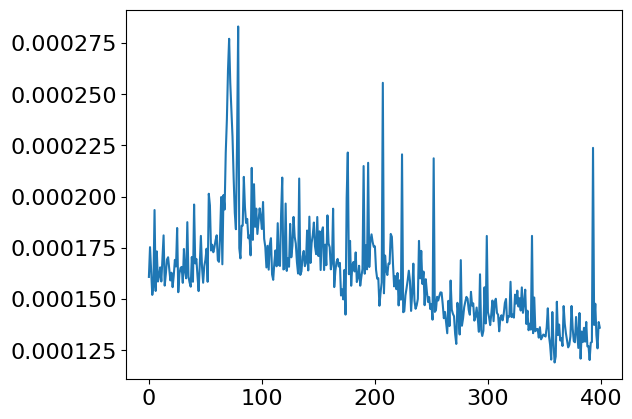

In [1211]:
plt.plot(losses_vae[100:])
plt.show()

In [1212]:
model_vae.eval()

synth_vae, mu, logvar = model_vae(data_wo_x.unsqueeze(1).to(device))
synth_vae = synth_vae.squeeze(1).detach().cpu()
left = synth_vae.squeeze(1)[:, :pos]
right = synth_vae.squeeze(1)[:, pos:]
synth_vae = torch.cat((left, X_for_sc, right), dim=1)
synth_df = pd.DataFrame(synth_vae.numpy(), columns=data.columns[:-1])

In [1213]:
# synth_pred = xgb.predict(synth_df)

# plt.scatter(y_test.loc[idx_sc].values, xgb.predict(data.loc[idx_sc]), alpha=0.8, label='Real bad X')
# plt.scatter(y_test.loc[idx_sc].values, synth_pred, alpha=0.8, label='Synth bad X')

# plt.legend()
# plt.show()

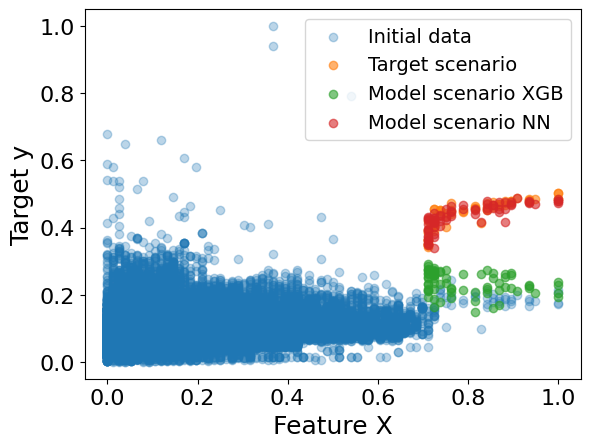

In [1214]:
# plt.scatter(X_test['floor'].loc[idx], y_test.loc[idx])
# plt.scatter(X_test['floor'].loc[idx], f(y_test.loc[idx]))
# plt.scatter(X_test['floor'].loc[idx], xgb.predict(synth_df))

# plt.show()


plt.scatter(data['floor'], data['pricemetr'], alpha=0.3, label='Initial data')
plt.scatter(data['floor'].loc[idx_sc], y_sc, alpha=0.6, label='Target scenario')
plt.scatter(data['floor'].loc[idx_sc], xgb.predict(synth_df), alpha=0.6, label='Model scenario XGB')
plt.scatter(data['floor'].loc[idx_sc], reg_model(torch.tensor(synth_df.values)).numpy().flatten(), alpha=0.6, label='Model scenario NN')

plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.legend()
plt.show()

In [1218]:
data.loc[idx_sc]

,Площадь квартиры,day,количество этажей всего,высота объекта,Этажность объекта подземная,Этажность объекта наземная,Количество квартир,Общая площадь объекта,Площадь жилых помещений объекта,lon,...,schoolprox,cemetprox,industrprox,daysin,daycos,liveratio,highratio,month,year,pricemetr
7450,0.165537,0.966667,0.855556,0.861308,0.304348,0.813953,0.115644,0.152399,0.226974,0.514591,...,0.158054,0.169050,0.029155,0.264418,0.058959,0.596276,0.032757,0.545455,0.142857,0.269738
43095,0.515558,0.933333,0.855556,0.861308,0.304348,0.813953,0.115644,0.152399,0.226974,0.514591,...,0.158054,0.169050,0.029155,0.238290,0.926037,0.596276,0.032757,0.909091,0.285714,0.243378
44078,0.115433,0.300000,0.622222,0.567572,0.086957,0.627907,0.142216,0.126977,0.195316,0.422932,...,0.119594,1.000000,0.087418,0.323160,0.967683,0.623667,0.022780,1.000000,0.285714,0.094836
44295,0.115433,0.333333,0.622222,0.567572,0.086957,0.627907,0.142216,0.126977,0.195316,0.422932,...,0.119594,1.000000,0.087418,0.331237,0.970658,0.623667,0.022780,1.000000,0.285714,0.093866
44303,0.112087,0.333333,0.622222,0.567572,0.086957,0.627907,0.142216,0.126977,0.195316,0.422932,...,0.119594,1.000000,0.087418,0.331237,0.970658,0.623667,0.022780,1.000000,0.285714,0.094836
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237962,0.425847,0.633333,0.655556,0.564209,0.086957,0.662791,0.200225,0.176618,0.274242,0.467019,...,0.126547,0.668850,0.037865,0.589884,0.008127,0.629093,0.018834,0.454545,1.000000,0.206347
238028,0.301547,0.633333,1.000000,1.000000,0.173913,1.000000,0.322605,0.440393,0.648836,0.508829,...,0.154332,0.181679,0.032301,0.589884,0.008127,0.582577,0.028034,0.454545,1.000000,0.204135
247126,0.205353,0.133333,0.666667,0.562635,0.086957,0.674419,0.688249,0.535895,0.751725,0.380041,...,0.280036,0.225474,0.080737,0.213111,0.090476,0.543856,0.017560,0.636364,1.000000,0.104616
249541,0.274780,0.733333,0.722222,0.566399,0.086957,0.732558,0.415419,0.252993,0.440545,0.456256,...,0.241827,0.715116,0.012969,0.101905,0.197457,0.728679,0.012913,0.636364,1.000000,0.098845


In [1215]:
synth_df

,Площадь квартиры,day,количество этажей всего,высота объекта,Этажность объекта подземная,Этажность объекта наземная,Количество квартир,Общая площадь объекта,Площадь жилых помещений объекта,lon,...,kidprox,schoolprox,cemetprox,industrprox,daysin,daycos,liveratio,highratio,month,year
0,0.997878,0.938342,0.025188,0.999319,0.987707,0.999917,4.685360e-08,0.999915,0.999541,0.000654,...,0.000925,0.049703,0.000117,0.010152,0.691754,0.748803,0.996527,0.998409,0.395465,0.994802
1,0.999400,0.969974,0.000201,0.999956,0.999877,1.000000,7.572205e-08,0.999999,0.999993,0.000285,...,0.000043,0.001573,0.000001,0.002053,0.887984,0.786174,0.999887,0.999959,0.618519,0.999503
2,0.993471,0.419684,0.990867,0.998717,0.992115,0.999904,9.813029e-06,0.999927,0.999304,0.013506,...,0.035781,0.463333,0.000373,0.000176,0.780542,0.996632,0.998076,0.959433,0.296233,0.994002
3,0.991011,0.622190,0.528532,0.992331,0.986691,0.993707,1.499204e-03,0.998840,0.998323,0.020257,...,0.004249,0.642299,0.009254,0.007016,0.523270,0.947759,0.990052,0.994053,0.518246,0.992687
4,0.999796,0.925412,0.388726,0.999907,0.998965,0.999991,1.070564e-07,0.999991,0.999913,0.000549,...,0.001436,0.044252,0.000009,0.009150,0.703752,0.621463,0.998057,0.999640,0.048415,0.998940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,0.989441,0.918942,0.001819,0.998767,0.984144,0.999803,2.039976e-05,0.999152,0.995703,0.005434,...,0.001273,0.035598,0.000446,0.062790,0.393770,0.813792,0.993439,0.992743,0.250145,0.997846
66,0.999601,0.721777,0.014808,0.999786,0.999819,0.999999,1.137607e-08,0.999988,0.999976,0.000025,...,0.000038,0.004149,0.000005,0.002241,0.955195,0.957963,0.998109,0.999850,0.311865,0.998824
67,0.997861,0.752256,0.303628,0.999892,0.996542,0.999999,4.397310e-08,0.999995,0.999155,0.002101,...,0.003590,0.018623,0.000063,0.015068,0.942599,0.905718,0.999125,0.999718,0.249294,0.998852
68,0.987864,0.926990,0.485682,0.967413,0.989891,0.998784,3.583255e-05,0.999761,0.999766,0.000674,...,0.002833,0.079911,0.000113,0.090241,0.481791,0.930916,0.998382,0.999243,0.485426,0.996596


In [1206]:
# for i in range(0,20,3):
#     plt.hist(data.loc[idx_sc].values[:, i], bins=40, alpha=0.7)
#     plt.hist(synth_vae[:, i], bins=40, alpha=0.7)

#     plt.show()

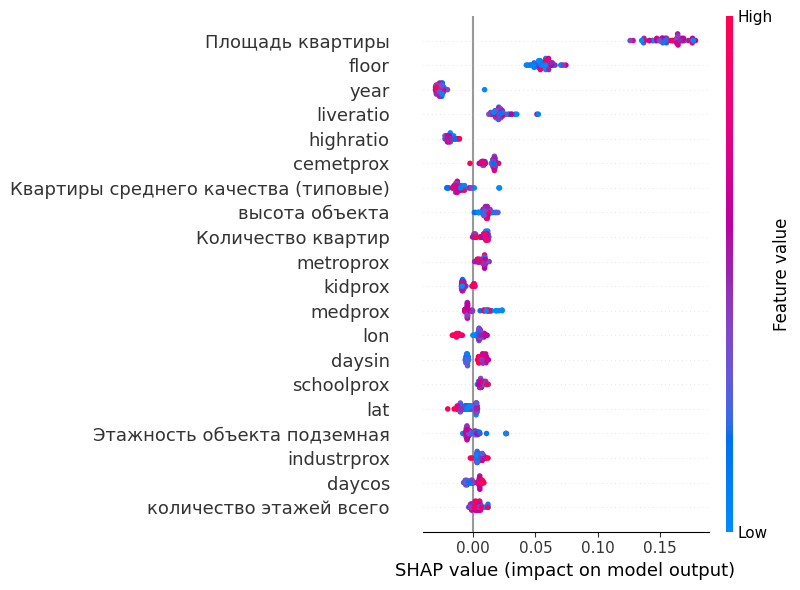

In [1207]:
explainer = shap.TreeExplainer(xgb)
# explanation = explainer(data.loc[idx_sc].drop('pricemetr', axis=1))
explanation = explainer(synth_df)
shap.summary_plot(explanation, plot_size=[8,6])

# Second model. Hard scenarios

### Определение значимости признаков

In [34]:
lr = LinearRegression()
lr.fit(X_train, y_train)
reg_coef = lr.coef_

# mean_absolute_percentage_error(y_test.values, lr.predict(X_test)), r2_score(y_test.values, lr.predict(X_test))
# plt.bar(np.arange(len(reg_coef)), reg_coef)
# plt.show()

In [35]:
from sklearn.feature_selection import f_regression, r_regression
from statsmodels.stats.multitest import multipletests

# X - матрица признаков (25 переменных), y - целевая переменная
f_scores, p_values = f_regression(X_train, y_train)

# Выведите результаты
# for i, (f, p) in enumerate(zip(f_scores, p_values)):
#     print(f"Признак {i+1}: F={f:.2f}, p={p:.4f}")

reject, corrected_p, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

In [36]:
explainer = shap.TreeExplainer(xgb)
explanation = explainer(X_train)
# shap.summary_plot(explanation, plot_size=[8,6])

In [37]:
feat_order_df = pd.DataFrame(np.array([X_train.columns,\
                                       reg_coef,\
                                       r_regression(X_train, y_train.values.flatten()),\
                                       reject,\
                                       explanation.values.mean(0)]).T)

feat_order_df = feat_order_df.sort_values(by=[1, 2, 3, 4], ascending=False)
feat_order_df

,0,1,2,3,4
3,высота объекта,0.337166,0.3984,True,-0.000654
7,Общая площадь объекта,0.087507,0.26079,True,-0.000574
25,year,0.069003,0.298744,True,-0.000493
12,Квартиры среднего качества (типовые),0.035682,-0.158641,True,0.000079
11,floor,0.035645,0.260261,True,0.000282
4,Этажность объекта подземная,0.023408,0.185099,True,-0.000029
10,lat,0.014337,0.261234,True,0.000083
17,schoolprox,0.009676,0.014598,True,0.000071
9,lon,0.009291,0.231256,True,0.000221
24,month,0.009068,0.001072,False,0.000055


In [ ]:
feat_order_names = feat_order_df[0].values
feat_order_names

In [40]:
feat_order_names

array(['высота объекта', 'Общая площадь объекта', 'year',
       'Квартиры среднего качества (типовые)', 'floor',
       'Этажность объекта подземная', 'lat', 'schoolprox', 'lon', 'month',
       'kidprox', 'day', 'Площадь жилых помещений объекта', 'daycos',
       'daysin', 'cemetprox', 'medprox', 'liveratio', 'metroprox',
       'rwprox', 'industrprox', 'Площадь квартиры',
       'количество этажей всего', 'Количество квартир', 'highratio',
       'Этажность объекта наземная'], dtype=object)

In [ ]:
def identify_feat_order(sc_type: int):
    if sc_type == 1:
        

In [ ]:
# import statsmodels.api as sm
# from statsmodels.formula.api import ols

# X_train_ols = sm.add_constant(X_train)
# ols_model = sm.OLS(y_train, X_train_ols)
# res_ols = ols_model.fit()
# print(res_ols.summary())
# res_ols.params

https://www.geeksforgeeks.org/interpreting-the-results-of-linear-regression-using-ols-summary/

In [ ]:
# sm.stats.anova_lm(res_ols, typ=1)

In [1262]:
# from scipy.stats import spearmanr

# # Для каждой количественной переменной:
# for col in ['Площадь квартиры']:  # замените на список количественных переменных
#     corr, p = spearmanr(data[col], data['pricemetr'])
#     print(f"{col}: Spearman rho={corr:.2f}, p-value={p:.4f}")
    
    
# from scipy.stats import kruskal

# # Пример: df содержит 25 независимых переменных и одну зависимую 'target'
# # Для каждой категориальной переменной:
# for col in ['day', 'высота объекта']:  # замените на список категориальных переменных
#     groups = [group['pricemetr'].values for _, group in data.groupby(col)]
#     stat, p = kruskal(*groups)
#     print(f"{col}: H-statistic={stat:.2f}, p-value={p:.4f}")

### Создание сценария

In [1088]:
feature_name = 'floor'

X_exp = data[['Общая площадь объекта', 'highratio', 'Этажность объекта наземная', 'Квартиры среднего качества (типовые)', feature_name]]
y_exp = data[['pricemetr']]

In [1089]:
xgb_exp = XGBRegressor()
xgb_exp.fit(X_exp, y_exp)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [1108]:
lr = LinearRegression(fit_intercept=False)
lr.fit(X_exp[[feature_name]], y_exp)
lr.coef_

array([[0.39289003]])

In [1109]:
r_regression(X_exp, y_exp.values.flatten())

array([ 0.26093203,  0.13569691,  0.33215912, -0.15809314,  0.26128821])

In [1110]:
z = 0.7
idx_sc = X_exp[X_exp[feature_name] > z].index
f = lambda arr: np.array(list(map(lambda y: 0.7 * y + 0.3, arr)))

y_sc = np.array(sorted(np.array(list(zip(np.arange(len(idx_sc)), X_exp.loc[idx_sc, feature_name].values.flatten(), \
                                f(y_exp.values.flatten())))), key=lambda x: x[1]))
y_sc[:, 2] = y_sc[:, 2] + 0.1 * np.linspace(0, 1, len(y_sc))
y_sc = np.array(sorted(y_sc, key=lambda x: x[0]))
y_sc = torch.tensor(y_sc[:, 2].astype('float32')).view(-1, 1)

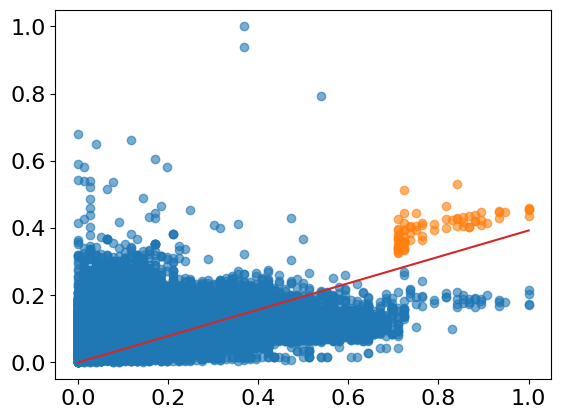

In [1112]:
plt.scatter(X_exp[feature_name], y_exp, alpha=0.6)
plt.scatter(X_exp.loc[idx_sc, feature_name], y_sc, alpha=0.6)
plt.plot(np.linspace(0, 1, 100), lr.coef_[0][0] * np.linspace(0, 1, 100), color='tab:red')

plt.show()

In [1113]:
feat_col_idx = np.where(X_exp.columns == feature_name)[0].item()

In [1116]:
num_cols_name = ['Общая площадь объекта', 'highratio']
cat_cols_name = ['Этажность объекта наземная', 'Квартиры среднего качества (типовые)']

In [998]:
from functools import partial

In [1118]:
def objective(trial, i):
    num_arr = [] 
    for col in num_cols_name:
        num_arr.append(trial.suggest_float(f"{col}", 0, 1, step=0.001))
        
    cat_arr = []
    for col in cat_cols_name:
        cat_arr.append(trial.suggest_categorical(f"{col}", X_exp[col].unique()))

    prediction = xgb_exp.predict([np.hstack([num_arr, cat_arr, [X_exp.loc[idx_sc].iloc[i, -1]]])])    
        
    objective = (prediction - y_sc.numpy()[i])**2
    # objective = (prediction - y.loc[idx_sc].iloc[0])**2
    if trial.should_prune():
            raise optuna.TrialPruned()
    
    return objective


scenario_df = pd.DataFrame(columns=np.hstack([num_cols_name, cat_cols_name]))
steps = tqdm(range(len(y_sc)))
optuna.logging.set_verbosity(optuna.logging.WARNING)

for i in steps:
    objective_with_args = partial(objective, i=i)
    study = optuna.create_study(sampler=optuna.samplers.TPESampler(), pruner=optuna.pruners.HyperbandPruner())
    study.optimize(objective_with_args, n_trials=100)
    
    one_point_df = pd.DataFrame(study.best_params.items()).T.iloc[[1]].rename(columns=dict(zip(np.arange(4), np.hstack([num_cols_name, cat_cols_name]))))
    
    scenario_df = pd.concat([scenario_df, one_point_df])

100%|██████████| 70/70 [01:19<00:00,  1.14s/it]


In [ ]:
# scenario_df = pd.DataFrame(study.best_params.items()).T
# scenario_df.columns = scenario_df.iloc[0]
# scenario_df = scenario_df.iloc[1:]
# scenario_df = pd.DataFrame(columns=np.hstack([num_cols_name, cat_cols_name]))
# scenario_df = pd.concat([scenario_df, pd.DataFrame(study.best_params.items()).T.iloc[[1]].rename(columns=dict(zip(np.arange(4), np.hstack([num_cols_name, cat_cols_name]))))])

In [1119]:
scenario_df = scenario_df.reset_index(drop=True)
scenario_df = pd.concat([scenario_df, X_exp.loc[idx_sc, feature_name].reset_index(drop=True)], axis=1).astype(float)
prediction_exp = xgb_exp.predict(scenario_df)

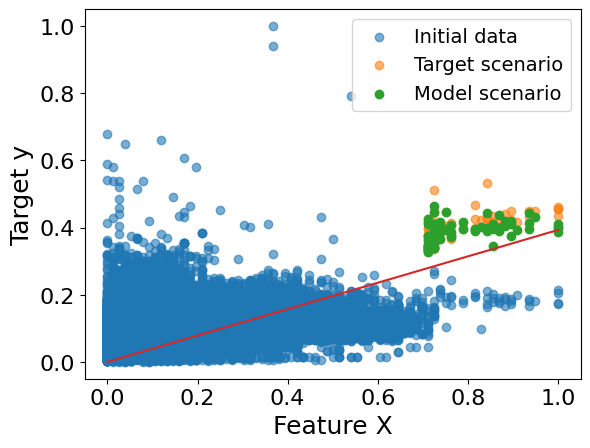

In [1120]:
plt.scatter(X_exp[feature_name], y_exp, alpha=0.6, label='Initial data')
plt.scatter(X_exp.loc[idx_sc, feature_name], y_sc, alpha=0.6, label='Target scenario')
plt.scatter(X_exp.loc[idx_sc, feature_name], prediction_exp, label='Model scenario')
plt.plot(np.linspace(0, 1, 100), lr.coef_[0][0] * np.linspace(0, 1, 100), color='tab:red')

plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.legend()
plt.show()

In [1121]:
scenario_df

,Общая площадь объекта,highratio,Этажность объекта наземная,Квартиры среднего качества (типовые),floor
0,0.742,0.721,0.197674,0.255731,0.723684
1,0.798,0.141,0.162791,0.877598,0.763158
2,0.917,0.804,0.197674,0.188707,0.710526
3,0.626,0.637,0.069767,0.739031,0.710526
4,0.391,0.350,0.174419,0.906005,0.710526
...,...,...,...,...,...
65,0.977,0.464,0.139535,0.906005,0.736842
66,0.580,0.140,0.139535,0.906005,1.000000
67,0.589,0.879,0.151163,0.906005,0.750000
68,0.721,0.813,0.197674,0.906005,0.828947


In [691]:
import gym
from stable_baselines3 import PPO

# Custom environment for scenario generation
class ScenarioEnv(gym.Env):
    def __init__(self):
        self.action_space = gym.spaces.Box(low=-1, high=1, shape=(4,))  # Scenario parameters
        self.observation_space = gym.spaces.Box(low=0, high=1, shape=(10,))  # State features
        self.state = 0.0

    def step(self, action):
        # Modify scenario parameters (action)
        # Run simulation and compute reward (e.g., realism score + challenge)
        reward = self._compute_reward(action)
        done = True  # Scenario complete
        return self.state, reward, done, {}

    def reset(self):
        # Initialize with base scenario
        return self.state

    def _compute_reward(self, action):
        # print(action)
        # Realism (adversarial score) + challenge (model failure)
        if np.mean(action) < 0.5:
            return 0
        else:
            return 1
        

env = ScenarioEnv()
model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=10000)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1        |
|    ep_rew_mean     | 0.08     |
| time/              |          |
|    fps             | 5121     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1           |
|    ep_rew_mean          | 0.12        |
| time/                   |             |
|    fps                  | 3620        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.026837692 |
|    clip_fraction        | 0.293       |
|    clip_range           | 0.2         |
|    entropy_loss         | -5.71       |
|    explained_variance   | 0           |
|    learning_rate        | 0.

In [692]:
model